<a href="https://colab.research.google.com/github/AbdelkrimElAyachi/models/blob/main/Sentiment_analyse_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP - Implémentation d’un modèle RNN pour l’analyse de sentiments

Dans ce notebook, nous allons implémenter un modèle de réseau de neurones récurrent (**RNN**) pour effectuer de l’analyse de sentiments sur des textes. L’objectif est de prédire automatiquement si un texte exprime un sentiment positif ou négatif. Les RNN sont particulièrement adaptés au traitement du langage naturel (NLP), car ils prennent en compte l’ordre des mots dans une phrase et peuvent mémoriser des informations provenant des étapes précédentes de la séquence.

Contrairement aux modèles CNN utilisés pour les images, les RNN travaillent sur des données séquentielles comme du texte, de l’audio ou des séries temporelles. Ils sont largement utilisés dans des tâches telles que la traduction automatique, la génération de texte et l’analyse de sentiments. Comprendre leur fonctionnement est donc essentiel pour aborder le domaine du NLP.

Le schéma général du modèle RNN utilisé dans ce TP est composé des éléments suivants :

* Une couche d’embedding permettant de transformer les mots en vecteurs numériques.
* Une couche récurrente (RNN) chargée de traiter les séquences de mots et de capturer les dépendances dans le texte.
* Une ou plusieurs couches entièrement connectées (fully connected) permettant de produire la prédiction finale.
* Une fonction d’activation adaptée à la classification binaire des sentiments.

Comme dans le TP précédent, nous allons coder le modèle, entraîner le réseau sur un dataset de textes annotés, puis évaluer ses performances sur des données de test. Enfin, nous analyserons rapidement les résultats obtenus ainsi que le comportement du modèle face à différents exemples de phrases.

La majeure partie de ce notebook suivra une structure similaire aux TPs précédents : préparation des données, création du modèle, entraînement, évaluation et visualisation des résultats. Nous passerons rapidement sur les parties déjà connues afin de nous concentrer principalement sur les spécificités des réseaux récurrents et du traitement du texte.


### 1. Initialisation et Importations

Ici, j'importe toutes les bibliothèques Python nécessaires pour mon projet. J'utilise `torch` pour les modèles de Deep Learning, `numpy` pour les opérations numériques, `datasets` pour charger les données, `matplotlib` pour visualiser mes résultats et `tqdm` pour suivre la progression de mes boucles. C'est comme préparer ma boîte à outils avant de commencer à bricoler !

Je fixe aussi une graine aléatoire (`seed`) pour s'assurer que mes résultats sont toujours les mêmes chaque fois que j'exécute le code. C'est super important pour que mes expériences soient reproductibles et pour que je puisse comparer différentes versions de mon modèle de manière juste.

In [ ]:
import collections
import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
# Removed torchtext dependency
import tqdm
import re # Added for custom tokenizer

In [ ]:
seed = 1234

np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

### 2. Chargement du Dataset IMDB

Je charge le célèbre dataset IMDB, qui contient des critiques de films. Chaque critique est associée à un sentiment : positif (1) ou négatif (0). Je le divise directement en ensembles d'entraînement (`train_data`) et de test (`test_data`). C'est le point de départ de mon modèle de classification de sentiment !

In [ ]:
!pip install datasets huggingface_hub pyarrow

In [ ]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

train_data = dataset["train"]
test_data = dataset["test"]

In [ ]:
train_data, test_data

(Dataset({
     features: ['text', 'label'],
     num_rows: 25000
 }),
 Dataset({
     features: ['text', 'label'],
     num_rows: 25000
 }))

### 3. Tokenisation du Texte

Pour que l'ordinateur puisse comprendre le texte, je dois d'abord le 'tokeniser', c'est-à-dire le découper en mots individuels (ou tokens). J'utilise un 'tokenizer' simple basé sur la division des mots. J'ai aussi défini une fonction pour prendre chaque exemple de critique, le tokeniser et limiter la longueur des séquences à `max_length` (256 ici). Si une critique est plus longue, je la coupe, si elle est plus courte, je la garde telle quelle. Cela aide à avoir des séquences de taille gérable pour le modèle.

In [ ]:
def basic_english_tokenizer(text):
    # Convert to lowercase
    text = text.lower()
    # Find all words (alphanumeric sequences and apostrophes)
    # This tokenizer splits on non-alphanumeric characters and keeps contractions intact
    tokens = re.findall(r"\b\w+(?:'\w+)?\b", text)
    return tokens

tokenizer = basic_english_tokenizer # Assign our custom tokenizer

In [ ]:
def tokenize_example(example, tokenizer, max_length):
    tokens = tokenizer(example["text"])[:max_length]
    length = len(tokens)
    return {"tokens": tokens, "length": length}

In [ ]:
max_length = 256

train_data = train_data.map(
    tokenize_example, fn_kwargs={"tokenizer": tokenizer, "max_length": max_length}
)
test_data = test_data.map(
    tokenize_example, fn_kwargs={"tokenizer": tokenizer, "max_length": max_length}
)

### 4. Séparation des Données d'Entraînement et de Validation

Après avoir tokenisé les données d'entraînement, je les divise en deux sous-ensembles : l'un pour l'entraînement (`train_data`) et l'autre pour la validation (`valid_data`). La validation me permet de surveiller la performance de mon modèle pendant l'entraînement sur des données qu'il n'a pas directement 'apprises'. Cela m'aide à détecter si mon modèle 'surapprend' (overfitting) sur les données d'entraînement.

In [ ]:
test_size = 0.25

train_valid_data = train_data.train_test_split(test_size=test_size)
train_data = train_valid_data["train"]
valid_data = train_valid_data["test"]

### 5. Construction du Vocabulaire Personnalisé

Je crée un vocabulaire à partir de tous les mots uniques présents dans mes données d'entraînement, en implémentant une classe `CustomVocab`. J'ai défini un `min_freq` de 5, ce qui signifie que seuls les mots qui apparaissent au moins 5 fois seront inclus dans mon vocabulaire. Les mots moins fréquents ou inconnus seront remplacés par le token `<unk>` (unknown). J'ajoute aussi un token `<pad>` (padding) pour uniformiser la longueur des séquences plus tard. C'est comme créer un dictionnaire pour le modèle !

In [ ]:
class CustomVocab:
    def __init__(self, token_frequencies, min_freq, specials):
        self.stoi = {}  # string to index
        self.itos = []  # index to string
        self.unk_token = "<unk>"
        self.pad_token = "<pad>"

        # Add special tokens first
        for token in specials:
            self.add_token(token)

        # Filter tokens by min_freq and add to vocab
        # Sort tokens by frequency in descending order, then alphabetically for ties
        sorted_tokens = sorted(token_frequencies.items(), key=lambda x: (-x[1], x[0]))
        for token, freq in sorted_tokens:
            if freq >= min_freq and token not in self.stoi:
                self.add_token(token)

        self.default_index = self.stoi.get(self.unk_token)

    def add_token(self, token):
        if token not in self.stoi:
            self.stoi[token] = len(self.itos)
            self.itos.append(token)

    def lookup_indices(self, tokens):
        # Returns a list of numerical indices for a list of tokens
        return [self.stoi.get(token, self.default_index) for token in tokens]

    def __len__(self):
        return len(self.itos)

    def __getitem__(self, token):
        # Allows vocab["word"] to return the index, with unk_token if not found
        return self.stoi.get(token, self.default_index)

    def get_itos(self):
        # Returns the list of tokens in order of their indices
        return self.itos

    def set_default_index(self, index):
        self.default_index = index

# Replacement for torchtext.vocab.build_vocab_from_iterator
def build_custom_vocab(iterator, min_freq, specials):
    token_frequencies = collections.defaultdict(int)
    # The iterator already yields individual tokens (words), so iterate directly over them.
    for token in iterator:
        token_frequencies[token] += 1
    return CustomVocab(token_frequencies, min_freq, specials)

min_freq = 5
special_tokens = ["<unk>", "<pad>"]

# Collect all tokens from the training data to build the vocabulary
all_tokens_iterator = (token for example in train_data["tokens"] for token in example)
vocab = build_custom_vocab(all_tokens_iterator, min_freq=min_freq, specials=special_tokens)


In [ ]:
unk_index = vocab[vocab.unk_token] # Get index of unknown token from custom vocab
pad_index = vocab[vocab.pad_token] # Get index of padding token from custom vocab

In [ ]:
vocab.set_default_index(unk_index) # Set the default index for unknown tokens

### 6. Numérisation des Exemples

Maintenant que j'ai mon vocabulaire, je dois transformer les mots (tokens) de chaque critique en leurs indices numériques correspondants dans le vocabulaire. C'est ce que fait la fonction `numericalize_example`. Le modèle travaille avec des nombres, pas avec du texte brut. Cette étape convertit toutes mes données tokenisées en une séquence d'IDs numériques.

In [ ]:
def numericalize_example(example, vocab):
    ids = vocab.lookup_indices(example["tokens"])
    return {"ids": ids}

In [ ]:
train_data = train_data.map(numericalize_example, fn_kwargs={"vocab": vocab})
valid_data = valid_data.map(numericalize_example, fn_kwargs={"vocab": vocab})
test_data = test_data.map(numericalize_example, fn_kwargs={"vocab": vocab})

Map:   0%|          | 0/18750 [00:00<?, ? examples/s]

Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

### 7. Préparation des DataLoader

Pour rendre les données utilisables par le modèle PyTorch, je les mets au format `torch` et je crée des `DataLoader`s. Un `DataLoader` prend soin de regrouper les exemples en 'batchs' (paquets de données) et de les 'padder' (remplir avec des zéros, ou `<pad_index>`) afin que toutes les séquences d'un même batch aient la même longueur. J'ai une fonction `get_collate_fn` pour gérer ce padding et une fonction `get_data_loader` pour créer mes chargeurs de données d'entraînement, de validation et de test. Le `shuffle=True` pour le `train_data_loader` est important pour mélanger les données à chaque époque et aider le modèle à généraliser.

In [ ]:
train_data = train_data.with_format(type="torch", columns=["ids", "label", "length"])
valid_data = valid_data.with_format(type="torch", columns=["ids", "label", "length"])
test_data = test_data.with_format(type="torch", columns=["ids", "label", "length"])

In [ ]:
train_data[0]

{'label': tensor(1),
 'length': tensor(118),
 'ids': tensor([  171,    12,     7,   182,   855,    27,     5,     2,   113,    91,
           937,    44,     6,  1553,     2,   381,     5,     2,   181,     6,
           777,    12,    15,     7,     6,   777,  2315,   428,    10,   357,
            13,     2,   388,  1189,    68,     3,    55,     5, 11178,     2,
          9363,    14,   771,  8208,  5657,   193,    30,     4,  3664,  3500,
            14,   219,     3, 10822,    45,     5,    13,  3219,   360,     3,
           664, 22131,  5666,  2850, 13057,   241,     9,    12,    15,  1142,
            29,    14,   118,   179,     6,    28,   540,   172,    16,     3,
            27,  2013,  1467,     9,     2,  5443,    26,  4243,     7,    33,
          2867,     6,    30,     2,    21,   274,  1150,   208,  2735,     4,
         17643,  3699,   582,  5046,     6,  2552,     4,  2038,  1238, 21549,
             7,     3,  8087,   137,    64,    12,    15,  4423])}

In [ ]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_ids = [i["ids"] for i in batch]
        batch_ids = nn.utils.rnn.pad_sequence(
            batch_ids, padding_value=pad_index, batch_first=True
        )
        batch_length = [i["length"] for i in batch]
        batch_length = torch.stack(batch_length)
        batch_label = [i["label"] for i in batch]
        batch_label = torch.stack(batch_label)
        batch = {"ids": batch_ids, "length": batch_length, "label": batch_label}
        return batch

    return collate_fn

In [ ]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )
    return data_loader

In [ ]:
batch_size = 512

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

### 8. Définition du Modèle LSTM

C'est le cœur de mon projet : l'architecture du modèle ! J'utilise un réseau de neurones récurrent de type LSTM (Long Short-Term Memory) bidirectionnel. Voici les couches principales :
- **`embedding`**: Convertit les IDs numériques des mots en vecteurs denses (embeddings), ce qui permet au modèle de comprendre les relations sémantiques entre les mots.
- **`lstm`**: Une couche LSTM bidirectionnelle. Le modèle lit la séquence de mots à la fois de gauche à droite et de droite à gauche, ce qui l'aide à mieux saisir le contexte global de la phrase.
- **`fc` (Fully Connected)**: Une couche linéaire qui prend la sortie finale des couches LSTM et la projette vers la dimension de sortie, qui est le nombre de classes (ici, 2 pour positif/négatif).
- **`dropout`**: Une technique de régularisation pour éviter le surapprentissage en désactivant aléatoirement certains neurones pendant l'entraînement.

In [ ]:
class LSTM(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        n_layers,
        bidirectional,
        dropout_rate,
        pad_index,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_index)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            n_layers,
            bidirectional=bidirectional,
            dropout=dropout_rate,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, ids, length):
        # ids = [batch size, seq len]
        # length = [batch size]
        embedded = self.dropout(self.embedding(ids))
        # embedded = [batch size, seq len, embedding dim]
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, length, batch_first=True, enforce_sorted=False
        )
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        # hidden = [n layers * n directions, batch size, hidden dim]
        # cell = [n layers * n directions, batch size, hidden dim]
        output, output_length = nn.utils.rnn.pad_packed_sequence(packed_output)
        # output = [batch size, seq len, hidden dim * n directions]
        if self.lstm.bidirectional:
            hidden = self.dropout(torch.cat([hidden[-1], hidden[-2]], dim=-1))
            # hidden = [batch size, hidden dim * 2]
        else:
            hidden = self.dropout(hidden[-1])
            # hidden = [batch size, hidden dim]
        prediction = self.fc(hidden)
        # prediction = [batch size, output dim]
        return prediction

### 9. Initialisation du Modèle et des Embeddings

Ici, je configure les hyperparamètres de mon modèle comme la taille du vocabulaire, la dimension des embeddings, la dimension cachée des LSTM, etc. Je crée une instance de ma classe `LSTM` avec ces paramètres.

Ensuite, j'initialise les poids du modèle de manière spécifique (`xavier_normal_` et `orthogonal_`) pour aider à la convergence. Pour la couche `embedding`, les représentations des mots sont initialisées aléatoirement par défaut. Si des embeddings de mots pré-entraînés étaient nécessaires, il faudrait les charger à partir d'une source externe et les assigner manuellement à `model.embedding.weight.data`.

In [ ]:
vocab_size = len(vocab)
embedding_dim = 300
hidden_dim = 300
output_dim = len(train_data.unique("label"))
n_layers = 2
bidirectional = True
dropout_rate = 0.5

model = LSTM(
    vocab_size,
    embedding_dim,
    hidden_dim,
    output_dim,
    n_layers,
    bidirectional,
    dropout_rate,
    pad_index,
)

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 10,344,602 trainable parameters


In [ ]:
def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)
    elif isinstance(m, nn.LSTM):
        for name, param in m.named_parameters():
            if "bias" in name:
                nn.init.zeros_(param)
            elif "weight" in name:
                nn.init.orthogonal_(param)

In [ ]:
model.apply(initialize_weights)

LSTM(
  (embedding): Embedding(22446, 300, padding_idx=1)
  (lstm): LSTM(300, 300, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=600, out_features=2, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

### 10. Optimiseur, Fonction de Perte et Configuration du Périphérique

Je choisis mon optimiseur (`Adam`), qui est un algorithme populaire pour mettre à jour les poids du modèle pendant l'entraînement afin de minimiser la perte. Je définis aussi ma fonction de perte (`CrossEntropyLoss`), qui mesure à quel point les prédictions de mon modèle sont éloignées des vraies étiquettes. C'est ce que le modèle essaie de minimiser.

Enfin, je m'assure que mon modèle et ma fonction de perte sont déplacés sur le bon 'périphérique' (`device`). Si un GPU est disponible (comme dans Colab avec un accélérateur), j'utilise `cuda` pour des calculs beaucoup plus rapides ; sinon, j'utilise le CPU. C'est crucial pour l'efficacité de l'entraînement !

In [ ]:
lr = 5e-4

optimizer = optim.Adam(model.parameters(), lr=lr)

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [ ]:
model = model.to(device)
criterion = criterion.to(device)

### 11. Fonctions d'Entraînement et d'Évaluation

J'ai créé deux fonctions importantes : `train` et `evaluate`.
- La fonction `train` met le modèle en mode entraînement (`model.train()`), parcourt les données d'un `dataloader`, calcule les prédictions, la perte et l'exactitude. Ensuite, elle effectue une rétropropagation (`loss.backward()`) et met à jour les poids du modèle (`optimizer.step()`).
- La fonction `evaluate` met le modèle en mode évaluation (`model.eval()`) et fait la même chose, mais sans mettre à jour les poids. C'est pour obtenir une mesure juste de la performance du modèle.
- La fonction `get_accuracy` calcule simplement le pourcentage de prédictions correctes.

In [ ]:
def train(dataloader, model, criterion, optimizer, device):
    model.train()
    epoch_losses = []
    epoch_accs = []
    for batch in tqdm.tqdm(dataloader, desc="training..."):
        ids = batch["ids"].to(device)
        length = batch["length"]
        label = batch["label"].to(device)
        prediction = model(ids, length)
        loss = criterion(prediction, label)
        accuracy = get_accuracy(prediction, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        epoch_accs.append(accuracy.item())
    return np.mean(epoch_losses), np.mean(epoch_accs)

In [ ]:
def evaluate(dataloader, model, criterion, device):
    model.eval()
    epoch_losses = []
    epoch_accs = []
    with torch.no_grad():
        for batch in tqdm.tqdm(dataloader, desc="evaluating..."):
            ids = batch["ids"].to(device)
            length = batch["length"]
            label = batch["label"].to(device)
            prediction = model(ids, length)
            loss = criterion(prediction, label)
            accuracy = get_accuracy(prediction, label)
            epoch_losses.append(loss.item())
            epoch_accs.append(accuracy.item())
    return np.mean(epoch_losses), np.mean(epoch_accs)

In [ ]:
def get_accuracy(prediction, label):
    batch_size, _ = prediction.shape
    predicted_classes = prediction.argmax(dim=-1)
    correct_predictions = predicted_classes.eq(label).sum()
    accuracy = correct_predictions / batch_size
    return accuracy

### 12. Boucle d'Entraînement

C'est la boucle principale où le modèle apprend ! Je définis le nombre d'époques (`n_epochs`), ce qui correspond au nombre de fois où le modèle va parcourir l'ensemble des données d'entraînement.

À chaque époque :
1.  J'appelle la fonction `train` pour entraîner le modèle sur les données d'entraînement.
2.  J'appelle la fonction `evaluate` pour évaluer le modèle sur les données de validation.
3.  Je stocke les pertes et les exactitudes pour l'entraînement et la validation.
4.  Si la perte de validation actuelle est meilleure que la meilleure perte de validation précédente, je sauvegarde les poids du modèle. C'est important pour garder le 'meilleur' modèle, celui qui généralise le mieux !

In [ ]:
n_epochs = 10
best_valid_loss = float("inf")

metrics = collections.defaultdict(list)

for epoch in range(n_epochs):
    train_loss, train_acc = train(
        train_data_loader, model, criterion, optimizer, device
    )
    valid_loss, valid_acc = evaluate(valid_data_loader, model, criterion, device)
    metrics["train_losses"].append(train_loss)
    metrics["train_accs"].append(train_acc)
    metrics["valid_losses"].append(valid_loss)
    metrics["valid_accs"].append(valid_acc)
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "lstm.pt")
    print(f"epoch: {epoch}")
    print(f"train_loss: {train_loss:.3f}, train_acc: {train_acc:.3f}")
    print(f"valid_loss: {valid_loss:.3f}, valid_acc: {valid_acc:.3f}")

evaluating...: 100%|██████████| 13/13 [00:03<00:00,  4.25it/s]


epoch: 0
train_loss: 0.673, train_acc: 0.570
valid_loss: 0.615, valid_acc: 0.652


evaluating...: 100%|██████████| 13/13 [00:03<00:00,  3.79it/s]


epoch: 1
train_loss: 0.587, train_acc: 0.687
valid_loss: 0.523, valid_acc: 0.750


evaluating...: 100%|██████████| 13/13 [00:03<00:00,  4.09it/s]


...

epoch: 7
train_loss: 0.336, train_acc: 0.856
valid_loss: 0.490, valid_acc: 0.836


evaluating...: 100%|██████████| 13/13 [00:03<00:00,  3.87it/s]


epoch: 8
train_loss: 0.323, train_acc: 0.862
valid_loss: 0.449, valid_acc: 0.837


evaluating...: 100%|██████████| 13/13 [00:03<00:00,  3.83it/s]

epoch: 9
train_loss: 0.301, train_acc: 0.872
valid_loss: 0.373, valid_acc: 0.849


### 13. Visualisation des Métriques d'Entraînement

Ces blocs de code utilisent `matplotlib` pour tracer les courbes de perte et d'exactitude au fil des époques. C'est super utile pour comprendre comment mon modèle apprend. Je peux voir si la perte diminue, si l'exactitude augmente et si la perte de validation reste proche de la perte d'entraînement (pas de surapprentissage !).

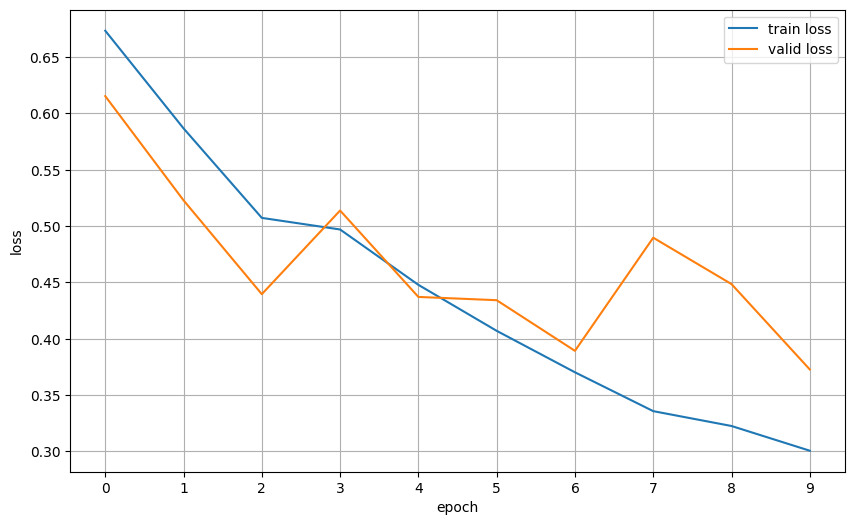

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics["train_losses"], label="train loss")
ax.plot(metrics["valid_losses"], label="valid loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

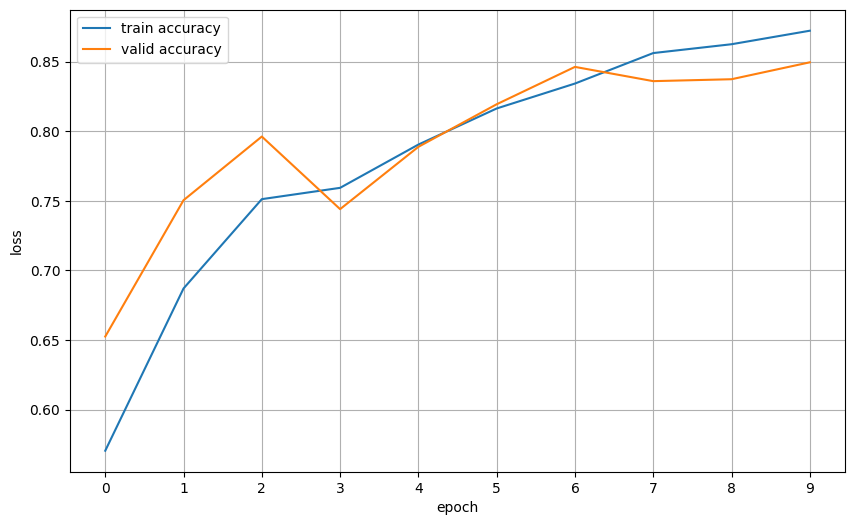

In [ ]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics["train_accs"], label="train accuracy")
ax.plot(metrics["valid_accs"], label="valid accuracy")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

### 14. Évaluation Finale sur les Données de Test

Après l'entraînement, je charge le meilleur modèle que j'ai sauvegardé (celui qui avait la plus faible perte de validation). Ensuite, j'appelle la fonction `evaluate` sur les données de test. C'est l'évaluation la plus importante car les données de test sont des données que le modèle n'a *jamais* vues pendant l'entraînement ou la validation. Cela me donne une estimation objective de la performance de mon modèle dans le monde réel.

In [ ]:
model.load_state_dict(torch.load("lstm.pt"))

test_loss, test_acc = evaluate(test_data_loader, model, criterion, device)

evaluating...: 100%|██████████| 49/49 [00:13<00:00,  3.60it/s]


In [ ]:
print(f"test_loss: {test_loss:.3f}, test_acc: {test_acc:.3f}")

test_loss: 0.376, test_acc: 0.846


### 15. Prédiction de Sentiment sur de Nouvelles Phrases

Cette fonction `predict_sentiment` me permet de tester mon modèle avec n'importe quelle nouvelle phrase. Elle prend une chaîne de texte, la tokenise, la numérise, la met au format PyTorch, et la passe au modèle. Le modèle renvoie une prédiction (0 pour négatif, 1 pour positif) et une probabilité associée. Je peux voir comment mon modèle se comporte sur des exemples concrets !

In [ ]:
def predict_sentiment(text, model, tokenizer, vocab, device):
    tokens = tokenizer(text)
    ids = vocab.lookup_indices(tokens)
    length = torch.LongTensor([len(ids)])
    tensor = torch.LongTensor(ids).unsqueeze(dim=0).to(device)
    prediction = model(tensor, length).squeeze(dim=0)
    probability = torch.softmax(prediction, dim=-1)
    predicted_class = prediction.argmax(dim=-1).item()
    predicted_probability = probability[predicted_class].item()
    return predicted_class, predicted_probability

In [ ]:
text = "This film is terrible!"

predict_sentiment(text, model, tokenizer, vocab, device)

(0, 0.9758809208869934)

In [ ]:
text = "This film is great!"

predict_sentiment(text, model, tokenizer, vocab, device)

(1, 0.9291847944259644)